In [21]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(42)

In [8]:
fmh = pd.read_csv(r"C:\Users\qstef\OneDrive\Bureaublad\Statistics & Data Science 2025-2026\Literature\4433ESSDSY - Essentials for Data Science\Materials\EfDS\08_dv\data\framingham.csv")
fmh.head()

,RANDID,SEX,AGE,SYSBP,DIABP,BPMEDS,CURSMOKE,EDUC,BMI,HEARTRTE,ANGINA,HOSPMI,STROKE,CVD,HYPERTEN,DEATH
0,2448,1,39,106.0,70.0,0.0,0,1.0,26.97,80.0,0,1,0,1,0,0
1,9428,1,48,127.5,80.0,0.0,1,0.0,25.34,75.0,0,0,0,0,0,0
2,14367,1,52,141.5,89.0,0.0,0,0.0,26.36,76.0,0,0,0,0,1,0
3,16365,1,43,162.0,107.0,0.0,1,0.0,23.61,93.0,0,0,0,0,1,0
4,20375,1,46,142.0,94.0,0.0,1,0.0,26.31,98.0,0,0,0,0,1,0


In [9]:
df = fmh[["RANDID","ANGINA","CVD","DEATH"]].head(3)
df

,RANDID,ANGINA,CVD,DEATH
0,2448,0,1,0
1,9428,0,0,0
2,14367,0,0,0


In [13]:
df_long = pd.melt(frame=df, id_vars="RANDID",
                  value_vars=["ANGINA","CVD","DEATH"],
                  var_name="EVENT",
                  value_name="STATUS")
df_long

,RANDID,EVENT,STATUS
0,2448,ANGINA,0
1,9428,ANGINA,0
2,14367,ANGINA,0
3,2448,CVD,1
4,9428,CVD,0
5,14367,CVD,0
6,2448,DEATH,0
7,9428,DEATH,0
8,14367,DEATH,0


at pandas level, global level

In [14]:
df_wide = df_long.pivot(index='RANDID', columns='EVENT', values='STATUS') # .reset_index().rename_axis(None,axis=1)
df_wide

EVENT,ANGINA,CVD,DEATH
RANDID,,,
2448,0,1,0
9428,0,0,0
14367,0,0,0


In [15]:
fmh.dtypes

RANDID        int64
SEX           int64
AGE           int64
SYSBP       float64
DIABP       float64
BPMEDS      float64
CURSMOKE      int64
EDUC        float64
BMI         float64
HEARTRTE    float64
ANGINA        int64
HOSPMI        int64
STROKE        int64
CVD           int64
HYPERTEN      int64
DEATH         int64
dtype: object

## merge

In [17]:
pip install names

     ---------------------------------------- 0.0/789.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/789.1 kB ? eta -:--:--
     ---------------------------------------- 789.1/789.1 kB 14.6 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for names: filename=names-0.3.0-py3-none-any.whl size=807033 sha256=c82c9fd8d45b460cee979d03fdf3e22bdd6076268a17190f1f21c610e3df4d7c
  Stored in directory: c:\users\qstef\appdata\local\pip\cache\wheels\13\7e\ea\4e627953109637974ec6b698a9b4b496e117e0fdfc0ecbc651
Successfully built names
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import names # pip install names
name_pool =  [names.get_first_name() for _ in range(10)]
df1 = pd.DataFrame({'name': rng.choice(name_pool,5, replace=False) , 'age':  rng.choice(range(18,80),5) })
df2 = pd.DataFrame({'name': rng.choice(name_pool,5, replace=False) , 'height':  rng.choice(range(150,190),5) })

In [23]:
df1

,name,age
0,Maude,23
1,Christine,50
2,Alonzo,78
3,Kenneth,63
4,Jennie,65


In [20]:
df2

,name,height
0,Tommy,187
1,Patricia,181
2,William,175
3,Rose,166
4,Maria,182


this is the inner by default 

In [25]:
df1.merge(df2, on="name")

,name,age,height
0,Maude,23,175
1,Alonzo,78,182
2,Jennie,65,181


In [ ]:
df1.merge(df2, on="name", how="inner") # default is inner, same as the one before

,name,age,height
0,Maude,23,175
1,Alonzo,78,182
2,Jennie,65,181


In [28]:
df1.merge(df2, on="name", how="outer")

,name,age,height
0,Alonzo,78.0,182.0
1,Christine,50.0,NaN
2,Jennie,65.0,181.0
3,Kenneth,63.0,NaN
4,Marcia,NaN,166.0
5,Maude,23.0,175.0
6,Steven,NaN,187.0


In [32]:
df1.name.duplicated().sum() # to check the repitions in a vector, do this before joining

np.int64(0)

reshaping and joining is needed for assignment C. (reshaping maybe less, but joining definitely)

# matplotlib

In [33]:
import matplotlib.pyplot as plt

In [39]:
type(df1.age)

pandas.Series

takes index as x-axis and values inside it as y-axis

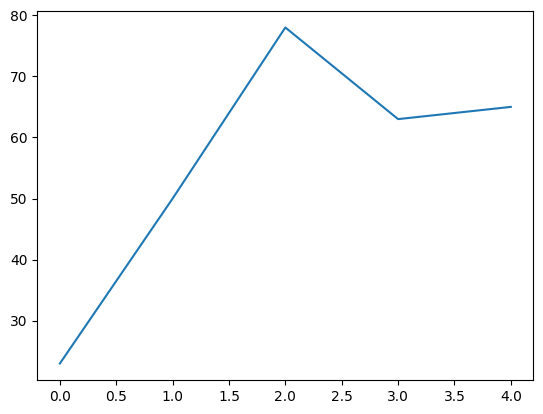

In [38]:
plt.plot(df1.age)
plt.show() # you dont see the return value

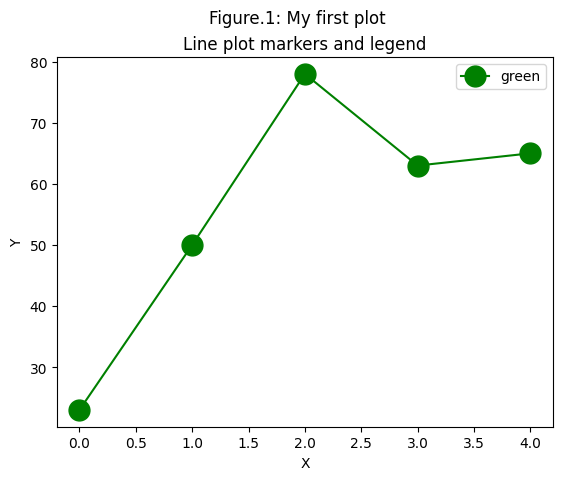

In [46]:
plt.plot(df1.age, "o-g", markersize=15); # circles as markers, straight line, color green
plt.xlabel('X')
plt.ylabel('Y')
plt.suptitle('Figure.1: My first plot')
plt.title('Line plot markers and legend')
plt.legend(['green'])
plt.show()

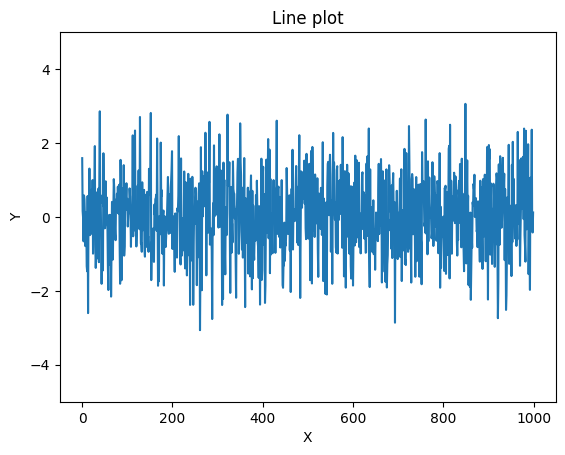

In [49]:
# single figure with a single plot
x_ = rng.standard_normal(1000)

fig = plt.figure() # creatse a figure object
ax = fig.add_subplot() # adds a single subplot / axes to the figure
ax.plot(x_) # plots the data on the subplot
ax.set_title('Line plot')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_ylim([-5,5]); # ; to not print the return value

Text(0.5, 0.98, 'My first multi-plot figure')

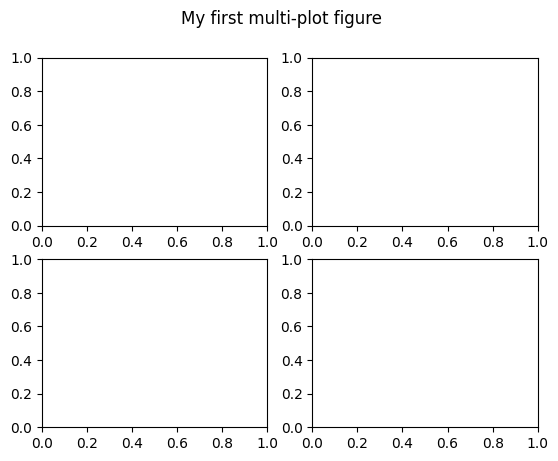

In [50]:
# multiple plots
x_ = rng.standard_normal(50)
y_ = rng.standard_normal(50)
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2) # sharex, sharey, figsize, dpi
fig.suptitle('My first multi-plot figure')

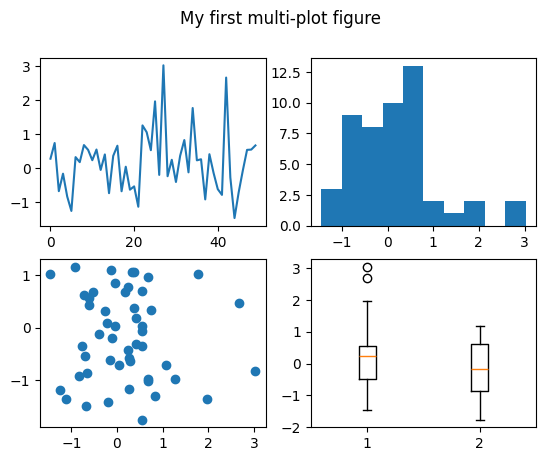

In [51]:
# multiple plots
x_ = rng.standard_normal(50)
y_ = rng.standard_normal(50)
fig, axes = plt.subplots(2,2) # sharex, sharey, figsize, dpi
fig.suptitle('My first multi-plot figure')
axes[0,0].plot(x_)
axes[0,1].hist(x_)
axes[1,0].scatter(x_,y_)
axes[1,1].boxplot([x_,y_]);

ValueError: not enough values to unpack (expected 3, got 2)

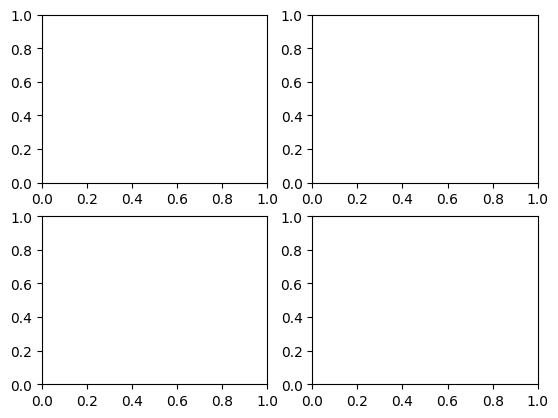

In [54]:
df = pd.DataFrame({'x': x_, 'y': y_})

fig, fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2)

In [56]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import seaborn as sns

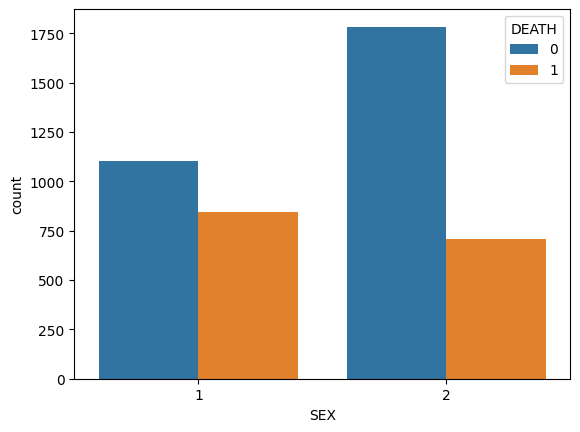

In [58]:
ax = sns.countplot(data=fmh,x='SEX', hue='DEATH')

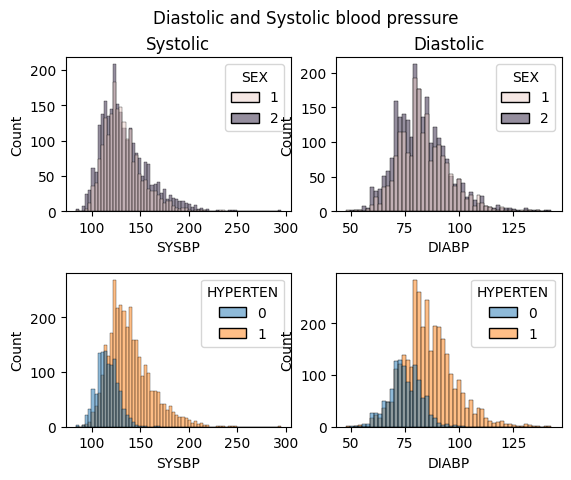

In [64]:
# Create a 2x2 grid plots
fig, axes = plt.subplots(2,2)

# add labels and titles
fig.suptitle("Diastolic and Systolic blood pressure")
axes[0,0].set_title("Systolic")
axes[0,1].set_title("Diastolic")

# place different plots inside the grid
sns.histplot(data=fmh,x='SYSBP', hue='SEX', ax=axes[0,0])
sns.histplot(data=fmh,x='DIABP', hue='SEX', ax=axes[0,1])
sns.histplot(data=fmh,x='SYSBP', hue='HYPERTEN', ax=axes[1,0])
sns.histplot(data=fmh,x='DIABP', hue='HYPERTEN', ax=axes[1,1])

# adjust horizontal space between plots see subplots_adjust for more options.
fig.subplots_adjust(hspace=.4) # [subplots_adjust](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots_adjust.html)

plt.show()

In [65]:
sex_ = fmh.SEX.astype('category')
sex_.cat.categories

Index([1, 2], dtype='int64')

In [69]:
sex_.cat.rename_categories(['male', 'female'])
print(sex_)

0       1
1       1
2       1
3       1
4       1
       ..
4429    2
4430    2
4431    2
4432    2
4433    2
Name: SEX, Length: 4434, dtype: category
Categories (2, int64): [1, 2]


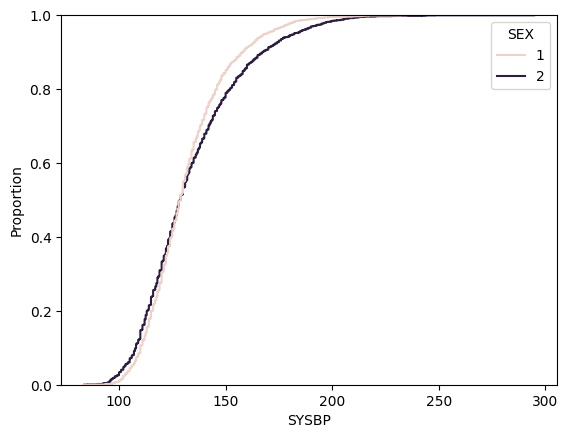

In [72]:
sns.ecdfplot(data=fmh, x='SYSBP', hue='SEX');

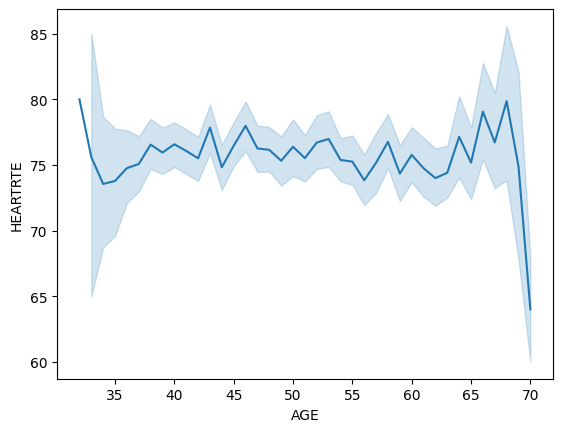

In [73]:
sns.lineplot(data=fmh, x='AGE', y='HEARTRTE');

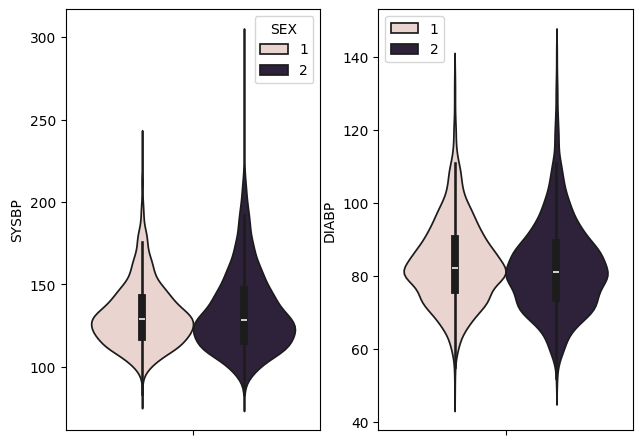

In [78]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.tight_layout()

sns.violinplot(data=fmh, y='SYSBP', hue='SEX', ax=ax1)
sns.violinplot(data=fmh, y='DIABP', hue='SEX', ax=ax2)

ax2.legend(loc="upper left");

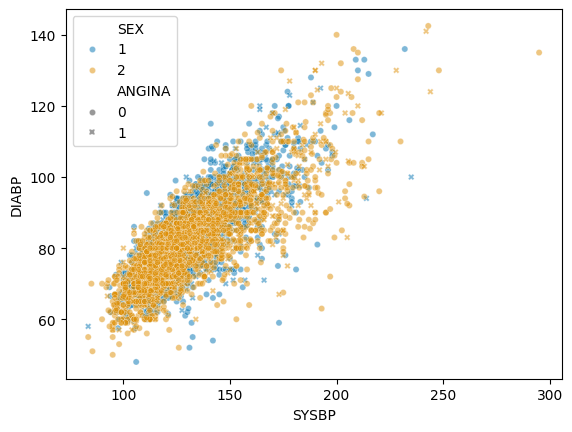

In [79]:
sns.scatterplot(fmh, x="SYSBP", y="DIABP", hue="SEX",style = "ANGINA", palette ="colorblind", s=20, alpha=0.5);

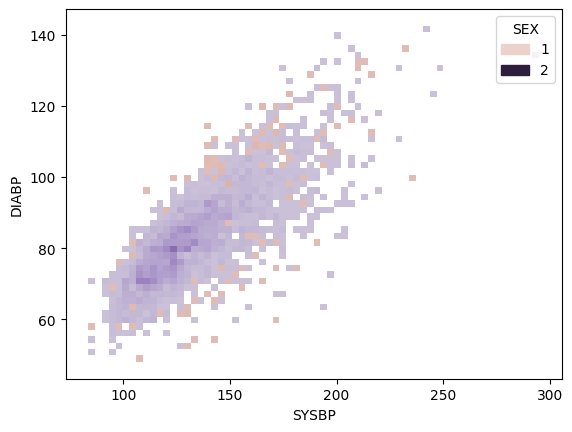

In [81]:
sns.histplot(data=fmh, x="SYSBP", y="DIABP", hue="SEX");

<Axes: xlabel='SYSBP', ylabel='DIABP'>

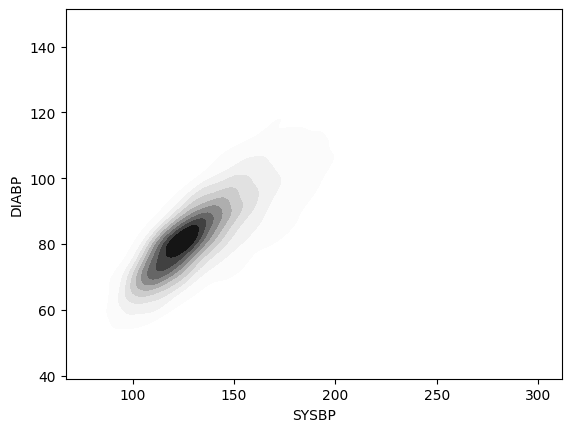

In [83]:
sns.kdeplot(fmh, x="SYSBP", y="DIABP", cmap="Greys", fill=True)

matplotlib.axes._axes.Axes

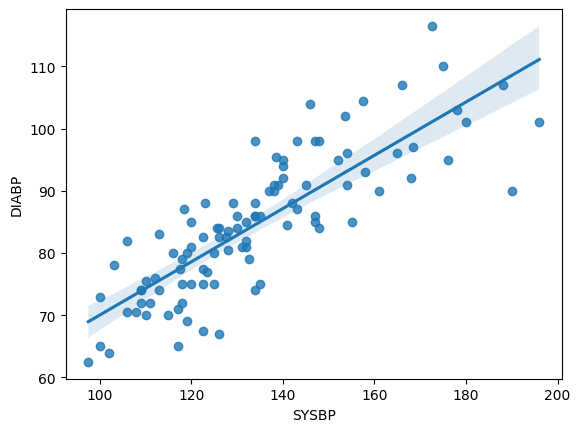

In [84]:
p1 = sns.regplot(fmh.sample(100),x="SYSBP", y="DIABP")
type(p1)

seaborn.axisgrid.FacetGrid

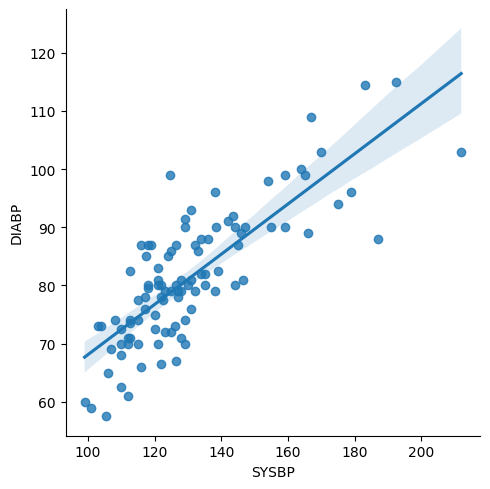

In [87]:
p2 = sns.lmplot(fmh.sample(100),x="SYSBP", y="DIABP")
type(p2)